# 01 - Dataset Preparation

This notebook prepares the cardiovascular Q&A dataset for the CardioBot NLP final project.

Steps:
1. Load Q&A parts
2. Merge into one dataset
3. Validate missing values and duplicates
4. Perform train/validation/test split
5. Save processed files
6. Show basic dataset statistics

In [19]:
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np

In [20]:
# setup path
BASE_DIR = Path.cwd()

# If running inside notebooks folder, move to project root
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"

print("Base directory:", BASE_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Results directory:", RESULTS_DIR)

Base directory: d:\CardioBot_NLP_Final
Raw data directory: d:\CardioBot_NLP_Final\data\raw
Processed data directory: d:\CardioBot_NLP_Final\data\processed
Results directory: d:\CardioBot_NLP_Final\results


In [21]:
# cek file QnA part
part_files = [
    PROCESSED_DIR / "qa_part1.jsonl",
    PROCESSED_DIR / "qa_part2.jsonl",
    PROCESSED_DIR / "qa_part3.jsonl",
    PROCESSED_DIR / "qa_part4.jsonl",
]

for file in part_files:
    print(f"{file.name}: {file.exists()}")

qa_part1.jsonl: True
qa_part2.jsonl: True
qa_part3.jsonl: True
qa_part4.jsonl: True


In [22]:
# function baca jsonl
def read_jsonl(path):
    data = []
    
    with open(path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            
            if not line:
                continue
            
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError as e:
                raise ValueError(f"Invalid JSON in {path.name}, line {line_num}: {e}")
    
    return data


def write_jsonl(path, data):
    path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(path, "w", encoding="utf-8") as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")

In [23]:
# load QnA part
all_qa = []

for file in part_files:
    rows = read_jsonl(file)
    print(f"Loaded {len(rows)} rows from {file.name}")
    all_qa.extend(rows)

print("\nTotal Q&A loaded:", len(all_qa))

Loaded 40 rows from qa_part1.jsonl
Loaded 40 rows from qa_part2.jsonl
Loaded 40 rows from qa_part3.jsonl
Loaded 40 rows from qa_part4.jsonl

Total Q&A loaded: 160


In [24]:
df = pd.DataFrame(all_qa)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (160, 5)


,id,topic,source,question,answer
0,qa_001,Angioplasty and Stent,Angioplasty and stent.txt,What is coronary angioplasty?,Coronary angioplasty is a procedure used to wi...
1,qa_002,Angioplasty and Stent,Angioplasty and stent.txt,What is the purpose of a stent during angiopla...,A stent is a short wire mesh tube placed insid...
2,qa_003,Angioplasty and Stent,Angioplasty and stent.txt,When is coronary angioplasty used?,Coronary angioplasty may be used when coronary...
3,qa_004,Angioplasty and Stent,Angioplasty and stent.txt,What are the benefits of coronary angioplasty?,Coronary angioplasty can improve blood flow th...
4,qa_005,Angioplasty and Stent,Angioplasty and stent.txt,How is coronary angioplasty performed?,Coronary angioplasty is performed using local ...


In [25]:
df.isnull().sum()

id          0
topic       0
source      0
question    0
answer      0
dtype: int64

In [26]:
required_columns = ["id", "topic", "source", "question", "answer"]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns exist.")

All required columns exist.


In [27]:
df["question_norm"] = df["question"].str.lower().str.strip()

duplicate_questions = df[df.duplicated("question_norm", keep=False)]

print("Number of duplicate questions:", duplicate_questions.shape[0])

duplicate_questions[["id", "topic", "question"]].head(10)

Number of duplicate questions: 0


,id,topic,question


In [28]:
df_clean = df.drop_duplicates(subset=["question_norm"], keep="first").copy()
df_clean = df_clean.drop(columns=["question_norm"])

df_clean = df_clean.reset_index(drop=True)
df_clean["id"] = [f"qa_{i+1:03d}" for i in range(len(df_clean))]

print("Before cleaning:", len(df))
print("After cleaning:", len(df_clean))

df_clean.head()

Before cleaning: 160
After cleaning: 160


,id,topic,source,question,answer
0,qa_001,Angioplasty and Stent,Angioplasty and stent.txt,What is coronary angioplasty?,Coronary angioplasty is a procedure used to wi...
1,qa_002,Angioplasty and Stent,Angioplasty and stent.txt,What is the purpose of a stent during angiopla...,A stent is a short wire mesh tube placed insid...
2,qa_003,Angioplasty and Stent,Angioplasty and stent.txt,When is coronary angioplasty used?,Coronary angioplasty may be used when coronary...
3,qa_004,Angioplasty and Stent,Angioplasty and stent.txt,What are the benefits of coronary angioplasty?,Coronary angioplasty can improve blood flow th...
4,qa_005,Angioplasty and Stent,Angioplasty and stent.txt,How is coronary angioplasty performed?,Coronary angioplasty is performed using local ...


In [29]:
topic_counts = df_clean["topic"].value_counts().sort_values(ascending=False)

print("Number of topics:", df_clean["topic"].nunique())
print("Total Q&A:", len(df_clean))

topic_counts

Number of topics: 26
Total Q&A: 160


topic
Cardiomyopathy                   12
Stroke                           12
Heart Valve Disease               8
Cholesterol                       8
Heart Anatomy and Function        7
Heart Failure                     7
Angioplasty and Stent             6
Blood Pressure Measurement        6
Cardiac Ablation                  6
Cardiac Rehabilitation            6
Pacemaker                         6
Angiography                       6
Arrhythmia                        6
Heart Disease Risk Factors        6
Hypertension                      6
Prevention                        6
Holter Monitor                    5
Peripheral Artery Disease         5
Atherosclerosis                   5
Coronary Artery Disease           5
Heart Disease                     5
Treatment for Heart Disease       5
Warning Signs of Heart Attack     5
Blood Flow                        4
Electrocardiogram                 4
Circulation                       3
Name: count, dtype: int64

In [30]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

train_data = []
val_data = []
test_data = []

for topic, group in df_clean.groupby("topic"):
    items = group.to_dict("records")
    random.shuffle(items)
    
    n = len(items)
    
    if n == 1:
        train_data.extend(items)
    elif n == 2:
        train_data.extend(items[:1])
        test_data.extend(items[1:])
    else:
        train_end = max(1, int(n * 0.70))
        val_end = train_end + max(1, int(n * 0.15))
        
        if val_end >= n:
            val_end = n - 1
        
        train_data.extend(items[:train_end])
        val_data.extend(items[train_end:val_end])
        test_data.extend(items[val_end:])

random.shuffle(train_data)
random.shuffle(val_data)
random.shuffle(test_data)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))
print("Total:", len(train_data) + len(val_data) + len(test_data))

Train size: 101
Validation size: 25
Test size: 34
Total: 160


In [31]:
def normalize_question(q):
    return " ".join(q.lower().strip().split())

train_q = {normalize_question(item["question"]) for item in train_data}
val_q = {normalize_question(item["question"]) for item in val_data}
test_q = {normalize_question(item["question"]) for item in test_data}

train_val_overlap = train_q & val_q
train_test_overlap = train_q & test_q
val_test_overlap = val_q & test_q

print("Train-Val overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Val-Test overlap:", len(val_test_overlap))

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("No exact question leakage detected.")
else:
    print("Leakage detected. Dataset needs fixing.")

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
No exact question leakage detected.


In [32]:
qa_full_path = PROCESSED_DIR / "qa_full.jsonl"
train_path = PROCESSED_DIR / "train.jsonl"
val_path = PROCESSED_DIR / "val.jsonl"
test_path = PROCESSED_DIR / "test.jsonl"

write_jsonl(qa_full_path, df_clean.to_dict("records"))
write_jsonl(train_path, train_data)
write_jsonl(val_path, val_data)
write_jsonl(test_path, test_data)

print("Saved files:")
print(qa_full_path)
print(train_path)
print(val_path)
print(test_path)

Saved files:
d:\CardioBot_NLP_Final\data\processed\qa_full.jsonl
d:\CardioBot_NLP_Final\data\processed\train.jsonl
d:\CardioBot_NLP_Final\data\processed\val.jsonl
d:\CardioBot_NLP_Final\data\processed\test.jsonl


In [33]:
old_train_path = DATA_DIR / "train_qa.jsonl"
old_test_path = DATA_DIR / "test_questions.json"

write_jsonl(old_train_path, train_data)

with open(old_test_path, "w", encoding="utf-8") as f:
    json.dump(test_data, f, indent=2, ensure_ascii=False)

print("Saved compatibility files:")
print(old_train_path)
print(old_test_path)

Saved compatibility files:
d:\CardioBot_NLP_Final\data\train_qa.jsonl
d:\CardioBot_NLP_Final\data\test_questions.json


In [34]:
summary = pd.DataFrame({
    "split": ["train", "validation", "test", "total"],
    "count": [len(train_data), len(val_data), len(test_data), len(df_clean)]
})

summary

,split,count
0,train,101
1,validation,25
2,test,34
3,total,160


## EDA

In [36]:
df_clean["question_word_count"] = df_clean["question"].apply(lambda x: len(x.split()))
df_clean["answer_word_count"] = df_clean["answer"].apply(lambda x: len(x.split()))

df_clean[["question_word_count", "answer_word_count"]].describe()

,question_word_count,answer_word_count
count,160.000000,160.00000
mean,6.362500,33.03125
std,2.075577,6.89583
min,3.000000,18.00000
25%,5.000000,28.75000
50%,6.000000,32.00000
75%,8.000000,37.00000
max,15.000000,58.00000


In [37]:
topic_counts = df_clean["topic"].value_counts().reset_index()
topic_counts.columns = ["topic", "count"]

topic_counts

,topic,count
0,Cardiomyopathy,12
1,Stroke,12
2,Heart Valve Disease,8
3,Cholesterol,8
4,Heart Anatomy and Function,7
5,Heart Failure,7
6,Angioplasty and Stent,6
7,Blood Pressure Measurement,6
8,Cardiac Ablation,6
9,Cardiac Rehabilitation,6


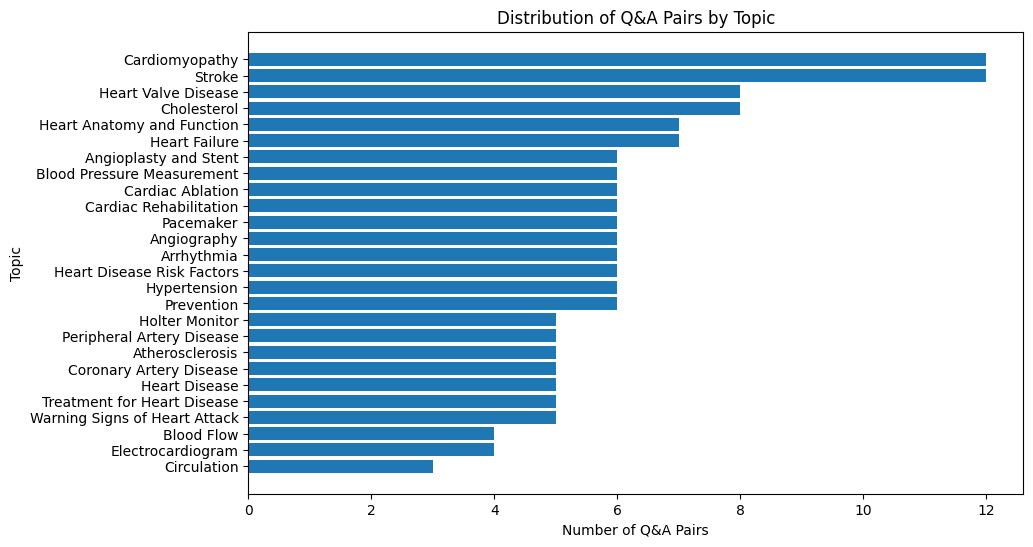

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(topic_counts["topic"], topic_counts["count"])
plt.xlabel("Number of Q&A Pairs")
plt.ylabel("Topic")
plt.title("Distribution of Q&A Pairs by Topic")
plt.gca().invert_yaxis()
plt.show()

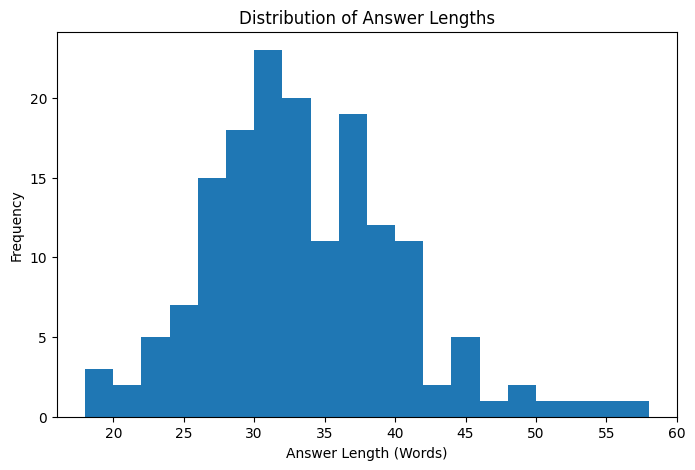

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["answer_word_count"], bins=20)
plt.xlabel("Answer Length (Words)")
plt.ylabel("Frequency")
plt.title("Distribution of Answer Lengths")
plt.show()

In [40]:
eda_summary = {
    "total_qa": len(df_clean),
    "total_topics": df_clean["topic"].nunique(),
    "train_size": len(train_data),
    "validation_size": len(val_data),
    "test_size": len(test_data),
    "avg_question_words": round(df_clean["question_word_count"].mean(), 2),
    "avg_answer_words": round(df_clean["answer_word_count"].mean(), 2),
    "min_answer_words": int(df_clean["answer_word_count"].min()),
    "max_answer_words": int(df_clean["answer_word_count"].max())
}

eda_summary

{'total_qa': 160,
 'total_topics': 26,
 'train_size': 101,
 'validation_size': 25,
 'test_size': 34,
 'avg_question_words': np.float64(6.36),
 'avg_answer_words': np.float64(33.03),
 'min_answer_words': 18,
 'max_answer_words': 58}

In [41]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=2)

topic_counts.to_csv(RESULTS_DIR / "topic_distribution.csv", index=False)

print("EDA summary saved.")

EDA summary saved.
